# Lead Scoring — Stage 1: Data Audit & EDA

**Objective:** Profile all five data sources, assess quality, and surface the signals that will drive the feature engineering pipeline.

> **How to read this notebook:** Each section follows the same pattern — *what we're doing*, *the code*, then *interpretation*. Decision flags are marked with 🔴 (problem), 🟡 (watch), or 🟢 (clear).

---


## 0. Setup & Imports

In [ ]:
import sys
from pathlib import Path
import pandas as pd

# ── Resolve project root ───────────────────────────────────────────
ROOT = next(p for p in Path().resolve().parents if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import config_999
from src.utils.io import load_master, load_raw

# ── Verify ─────────────────────────────────────────────────────────
print(f"Root   : {ROOT}")
print(f"CRM    : {config_999.RAW_FILES['crm']}")
print(f"Exists : {config_999.RAW_FILES['crm'].exists()}")

Root   : /home/cairo/code/portfolio/lead-scoring
CRM    : /home/cairo/code/portfolio/lead-scoring/data/raw/crm_leads.csv
Exists : True


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot defaults ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})
PALETTE = ['#2E6DA4', '#E8734A', '#48A868', '#9B59B6', '#E8C84A']
CONV_COLOR = '#2E6DA4'
BASE_COLOR = '#AACCE8'


## 1. Load & Preview All Tables

We have five data sources that will be joined on `lead_id`. Let's load them and do a first sanity check on shapes and types.


In [ ]:
tables_raw = load_raw()   # returns the same dict, keyed by table name

crm      = tables_raw["crm"]
web      = tables_raw["web"]
email    = tables_raw["email"]
trial    = tables_raw["trial"]
outcomes = tables_raw["outcomes"]

In [10]:
tables_raw.keys()

dict_keys(['crm', 'web', 'email', 'trial', 'outcomes'])

In [12]:
for name, df in tables_raw.items():
    print(f"{name:<12} {df.shape[0]:>6} {df.shape[1]:>5}  {list(df.columns)}")

crm             800    11  ['lead_id', 'created_date', 'country', 'industry', 'employee_count_bucket', 'annual_revenue_usd_k', 'job_title', 'is_decision_maker', 'lead_source', 'tech_stack', 'crm_stage']
web             800    13  ['lead_id', 'total_sessions', 'total_pageviews', 'avg_session_duration_sec', 'pricing_page_visits', 'demo_page_visits', 'case_study_views', 'roi_calculator_uses', 'careers_page_visits', 'blog_views', 'utm_source', 'days_since_last_visit', 'is_bot_suspect']
email           800    12  ['lead_id', 'emails_sent', 'emails_opened', 'emails_clicked', 'open_rate', 'click_to_open_rate', 'forms_submitted', 'content_downloads', 'webinar_attended', 'unsubscribed', 'hard_bounced', 'days_since_last_email_open']
trial           800     6  ['lead_id', 'trial_started', 'trial_logins', 'features_activated', 'days_active_in_trial', 'is_ghost_trial']
outcomes        800     6  ['lead_id', 'converted', 'days_to_conversion', 'deal_value_usd', 'disposition', 'conversion_probability_

## 2. ID Integrity Check

Before any analysis, we verify every table joins cleanly on `lead_id`. A mismatch here would silently corrupt any merged analysis.


In [14]:
base_ids = set(crm['lead_id'])

print("ID integrity check vs CRM (800 leads):")
print("─" * 45)
for name, df in tables_raw.items():
    ids = set(df['lead_id'])
    missing = base_ids - ids
    extra   = ids - base_ids
    status  = "✅ Perfect" if not missing and not extra else "⚠️  MISMATCH"
    print(f"  {name:<10} | unique: {len(ids):>3} | missing: {len(missing)} | extra: {len(extra)}  {status}")


ID integrity check vs CRM (800 leads):
─────────────────────────────────────────────
  crm        | unique: 800 | missing: 0 | extra: 0  ✅ Perfect
  web        | unique: 800 | missing: 0 | extra: 0  ✅ Perfect
  email      | unique: 800 | missing: 0 | extra: 0  ✅ Perfect
  trial      | unique: 800 | missing: 0 | extra: 0  ✅ Perfect
  outcomes   | unique: 800 | missing: 0 | extra: 0  ✅ Perfect


## 3. Missing Data Audit

Missing data in CRM fields is expected — sales reps don't always fill everything in. The key question is whether missingness is *random* or *informative* (i.e., does it correlate with conversion?). If it does, we need to be careful about how we impute.


In [15]:
# Join outcomes for CVR analysis
df = (crm
      .merge(web,      on='lead_id')
      .merge(email,    on='lead_id')
      .merge(trial,    on='lead_id')
      .merge(outcomes, on='lead_id'))

print(f"Master dataframe: {df.shape[0]} rows × {df.shape[1]} cols\n")

# Fields with nulls
all_missing = df.isnull().sum()
all_missing = all_missing[all_missing > 0].sort_values(ascending=False)

print(f"{'Field':<35} {'Missing':>7} {'%':>6}  CVR if missing  CVR if present  Decision")
print("─" * 95)
for field, n in all_missing.items():
    pct = n / len(df)
    mask = df[field].isnull()
    # Only compute CVR for fields where we have enough missing rows
    if mask.sum() >= 10 and 'converted' in df.columns:
        cvr_m = df[mask]['converted'].mean()
        cvr_p = df[~mask]['converted'].mean()
        diff  = abs(cvr_m - cvr_p)
        flag  = "🟡 Informative?" if diff > 0.03 else "🟢 MAR — safe to impute"
    else:
        cvr_m = cvr_p = float('nan')
        flag  = "—"
    print(f"  {field:<33} {n:>7,} {pct:>6.1%}  {cvr_m:>14.1%}  {cvr_p:>14.1%}  {flag}")


Master dataframe: 800 rows × 44 cols

Field                               Missing      %  CVR if missing  CVR if present  Decision
───────────────────────────────────────────────────────────────────────────────────────────────
  deal_value_usd                        596  74.5%            0.0%          100.0%  🟡 Informative?
  days_to_conversion                    596  74.5%            0.0%          100.0%  🟡 Informative?
  days_since_last_email_open            166  20.8%           18.1%           27.4%  🟡 Informative?
  annual_revenue_usd_k                  113  14.1%           28.3%           25.0%  🟡 Informative?
  job_title                              73   9.1%           28.8%           25.2%  🟡 Informative?
  country                                68   8.5%           26.5%           25.4%  🟢 MAR — safe to impute
  tech_stack                             66   8.2%           13.6%           26.6%  🟡 Informative?


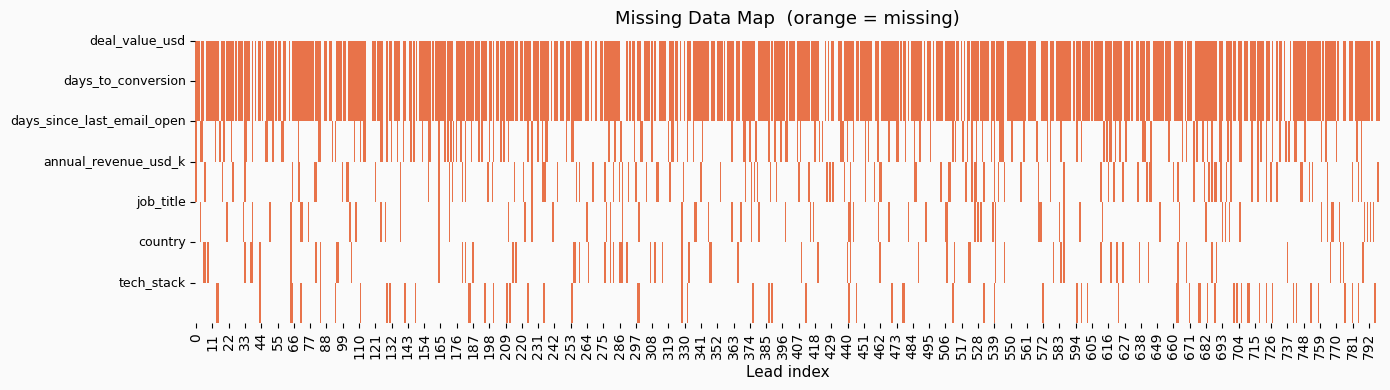

In [16]:
# Visualise missing data heatmap
fig, ax = plt.subplots(figsize=(14, 4))
missing_matrix = df[all_missing.index].isnull().astype(int)
sns.heatmap(
    missing_matrix.T,
    cmap=['#FAFAFA', '#E8734A'],
    cbar=False,
    linewidths=0,
    ax=ax,
    yticklabels=all_missing.index
)
ax.set_title('Missing Data Map  (orange = missing)', pad=12)
ax.set_xlabel('Lead index')
ax.set_yticks(range(len(all_missing)))
ax.set_yticklabels(all_missing.index, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Conversion Profile

The conversion rate determines everything downstream: class imbalance strategy, model threshold, and whether we have enough positive examples to train on.

**Key threshold:** we need ≥ 100 conversions to justify a Logistic Regression. Below that, we fall back to pure rule-based scoring.


In [17]:
n_total     = len(df)
n_converted = df['converted'].sum()
conv_rate   = df['converted'].mean()

print(f"Total leads       : {n_total:,}")
print(f"Converted (pos)   : {n_converted:,}  ({conv_rate:.1%})")
print(f"Not converted     : {n_total - n_converted:,}  ({1-conv_rate:.1%})")
print(f"Class ratio (pos:neg) : 1 : {(n_total-n_converted)/n_converted:.1f}")
print()
if n_converted >= 100:
    print("✅ Sufficient conversions for Logistic Regression (≥100 threshold met)")
else:
    print("🔴 Below 100 conversions — fall back to rule-based scoring only")


Total leads       : 800
Converted (pos)   : 204  (25.5%)
Not converted     : 596  (74.5%)
Class ratio (pos:neg) : 1 : 2.9

✅ Sufficient conversions for Logistic Regression (≥100 threshold met)


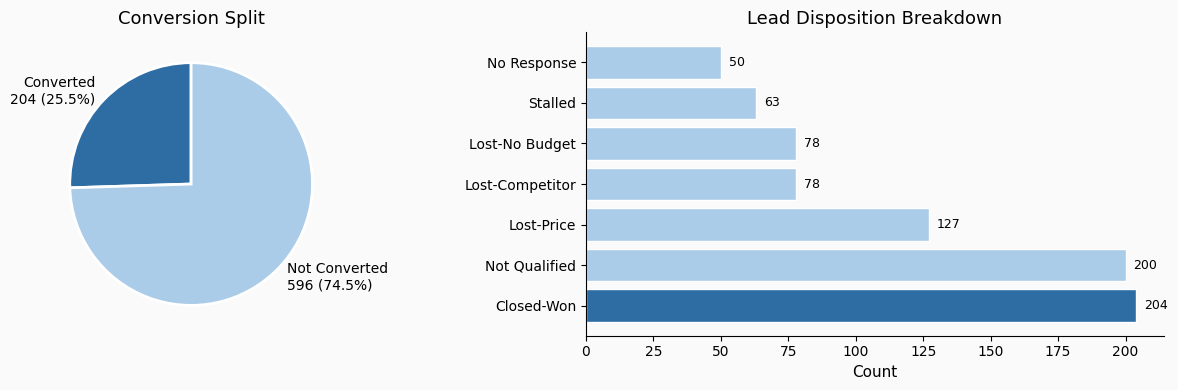

In [18]:
# Disposition breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: pie of converted vs not
ax = axes[0]
sizes  = [n_converted, n_total - n_converted]
labels = [f'Converted\n{n_converted} ({conv_rate:.1%})', f'Not Converted\n{n_total-n_converted} ({1-conv_rate:.1%})']
ax.pie(sizes, labels=labels, colors=[CONV_COLOR, BASE_COLOR],
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Conversion Split')

# Right: disposition bar
ax2 = axes[1]
disp = df['disposition'].value_counts()
colors_d = [CONV_COLOR if d == 'Closed-Won' else BASE_COLOR for d in disp.index]
bars = ax2.barh(disp.index, disp.values, color=colors_d, edgecolor='white')
for bar, v in zip(bars, disp.values):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             str(v), va='center', fontsize=9)
ax2.set_title('Lead Disposition Breakdown')
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()


## 5. Data Quality Flags

Three flags in the data identify contaminated records: `is_bot_suspect`, `is_ghost_trial`, `hard_bounced`. These should be *excluded from the training set* but retained for scoring (we still want to score all leads; we just don't want to learn from corrupted examples).


In [19]:
flags = {
    'Bot suspect (web)':    df['is_bot_suspect'] == 1,
    'Ghost trial':          df['is_ghost_trial'] == 1,
    'Hard bounced email':   df['hard_bounced'] == 1,
    'Unsubscribed':         df['unsubscribed'] == 1,
}

print(f"{'Flag':<28} {'n':>5} {'%':>6}  CVR  Recommendation")
print("─" * 70)
base = df['converted'].mean()
for label, mask in flags.items():
    n   = mask.sum()
    cvr = df[mask]['converted'].mean()
    lift = cvr / base
    rec = "❌ Exclude from training" if label in ['Bot suspect (web)', 'Ghost trial'] else "🔴 Negative signal — keep as feature"
    print(f"  {label:<26} {n:>5} {n/len(df):>6.1%} {cvr:>5.1%}  {rec}")

# Overlap: how many leads have multiple flags?
flag_df = pd.DataFrame({k: v.astype(int) for k, v in flags.items()})
multi = (flag_df.sum(axis=1) > 1).sum()
print(f"\nLeads with 2+ flags: {multi}")


Flag                             n      %  CVR  Recommendation
──────────────────────────────────────────────────────────────────────
  Bot suspect (web)             40   5.0% 27.5%  ❌ Exclude from training
  Ghost trial                   61   7.6% 26.2%  ❌ Exclude from training
  Hard bounced email            35   4.4% 22.9%  🔴 Negative signal — keep as feature
  Unsubscribed                  92  11.5%  8.7%  🔴 Negative signal — keep as feature

Leads with 2+ flags: 25


In [20]:
# Clean training set size after exclusions
bots   = df['is_bot_suspect'] == 1
ghosts = df['is_ghost_trial'] == 1
exclude_mask = bots | ghosts

train_clean = df[~exclude_mask]
print(f"Training set after exclusions:")
print(f"  Original   : {len(df):,} leads, {df['converted'].sum()} conversions")
print(f"  Excluded   : {exclude_mask.sum()} leads (bots + ghost trials)")
print(f"  Clean set  : {len(train_clean):,} leads, {train_clean['converted'].sum()} conversions ({train_clean['converted'].mean():.1%} CVR)")
print()
print("✅ Still above 100-conversion threshold — model training unaffected")


Training set after exclusions:
  Original   : 800 leads, 204 conversions
  Excluded   : 98 leads (bots + ghost trials)
  Clean set  : 702 leads, 177 conversions (25.2% CVR)

✅ Still above 100-conversion threshold — model training unaffected


## 6. CRM Stage — Data Leakage Check

`crm_stage` seems like a useful feature. But we need to verify it doesn't encode the outcome — i.e., that "Closed-Won" in CRM actually means converted. If CRM and outcomes disagree, using this feature would be **data leakage**.


In [21]:
stage_conv = df.groupby('crm_stage')['converted'].agg(['sum','count','mean']).rename(
    columns={'sum':'converted','count':'total','mean':'cvr'}).sort_values('cvr', ascending=False)
stage_conv['cvr'] = stage_conv['cvr'].map('{:.1%}'.format)
print("CRM Stage vs Conversion Rate:")
print(stage_conv.to_string())

# The critical anomaly
print()
anomaly = df[(df['crm_stage']=='Closed-Won') & (df['converted']==0)]
print(f"🔴 LEAKAGE FLAG: {len(anomaly)} leads with crm_stage='Closed-Won' but converted=0")
print(f"   These leads appear in dispositions: {anomaly['disposition'].value_counts().to_dict()}")
print()
print("Decision: EXCLUDE crm_stage from all features. It is partially stale/incorrect.")


CRM Stage vs Conversion Rate:
             converted  total    cvr
crm_stage                           
Contacted           54    169  32.0%
MQL                 41    147  27.9%
SQL                 27    102  26.5%
Opportunity         18     77  23.4%
New                 47    205  22.9%
Closed-Lost          9     43  20.9%
Closed-Won           8     57  14.0%

🔴 LEAKAGE FLAG: 49 leads with crm_stage='Closed-Won' but converted=0
   These leads appear in dispositions: {'Not Qualified': 13, 'Lost-Price': 11, 'Stalled': 9, 'Lost-Competitor': 9, 'No Response': 5, 'Lost-No Budget': 2}

Decision: EXCLUDE crm_stage from all features. It is partially stale/incorrect.


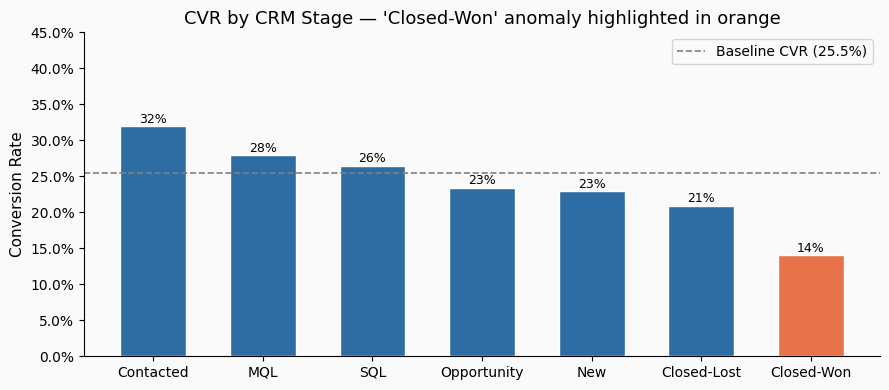

In [22]:
# Visualise the anomaly clearly
fig, ax = plt.subplots(figsize=(9, 4))
stages  = stage_conv.index.tolist()
cvr_vals = df.groupby('crm_stage')['converted'].mean().reindex(stages)

colors = ['#E8734A' if s == 'Closed-Won' else CONV_COLOR for s in stages]
bars = ax.bar(stages, cvr_vals, color=colors, edgecolor='white', width=0.6)
ax.axhline(df['converted'].mean(), color='grey', linestyle='--', linewidth=1.2, label=f'Baseline CVR ({df["converted"].mean():.1%})')

for bar, v in zip(bars, cvr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.0%}', ha='center', fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("CVR by CRM Stage — 'Closed-Won' anomaly highlighted in orange")
ax.set_ylabel("Conversion Rate")
ax.legend()
ax.set_ylim(0, 0.45)
plt.tight_layout()
plt.show()


## 7. Behavioral Signal Strength

The case framework assigns weights (+20 for pricing/demo, +10 for ROI calculator, etc.). Let's *verify* those weights against actual conversion lift before accepting them. If the data disagrees with the heuristic, the data wins.


In [23]:
clean = df[~(df['is_bot_suspect']==1) & ~(df['is_ghost_trial']==1)].copy()
base_cvr = clean['converted'].mean()

signals = {
    'pricing_page_visits > 0':   clean['pricing_page_visits'] > 0,
    'demo_page_visits > 0':      clean['demo_page_visits'] > 0,
    'roi_calculator_uses > 0':   clean['roi_calculator_uses'] > 0,
    'case_study_views > 0':      clean['case_study_views'] > 0,
    'blog_views > 3':            clean['blog_views'] > 3,
    'forms_submitted > 0':       clean['forms_submitted'] > 0,
    'content_downloads > 0':     clean['content_downloads'] > 0,
    'webinar_attended = 1':      clean['webinar_attended'] == 1,
    'trial_started = 1':         clean['trial_started'] == 1,
    'careers_page_visits > 0':   clean['careers_page_visits'] > 0,
    'unsubscribed = 1':          clean['unsubscribed'] == 1,
}

results = []
for label, mask in signals.items():
    n   = mask.sum()
    cvr = clean[mask]['converted'].mean()
    lift = cvr / base_cvr
    results.append({'Signal': label, 'n': n, 'CVR': cvr, 'Lift': lift})

sig_df = pd.DataFrame(results).sort_values('Lift', ascending=False)
sig_df['CVR_fmt']  = sig_df['CVR'].map('{:.1%}'.format)
sig_df['Lift_fmt'] = sig_df['Lift'].map('{:.2f}x'.format)
print(f"Baseline CVR: {base_cvr:.1%}\n")
print(sig_df[['Signal','n','CVR_fmt','Lift_fmt']].to_string(index=False))


Baseline CVR: 25.2%

                 Signal   n CVR_fmt Lift_fmt
pricing_page_visits > 0 276   45.3%    1.80x
   demo_page_visits > 0 172   41.9%    1.66x
    forms_submitted > 0 249   38.2%    1.51x
  content_downloads > 0 275   33.1%    1.31x
   case_study_views > 0 267   30.0%    1.19x
      trial_started = 1 210   27.1%    1.08x
   webinar_attended = 1  77   26.0%    1.03x
roi_calculator_uses > 0 120   25.8%    1.02x
         blog_views > 3 209   22.0%    0.87x
careers_page_visits > 0 350   20.3%    0.80x
       unsubscribed = 1  75    8.0%    0.32x


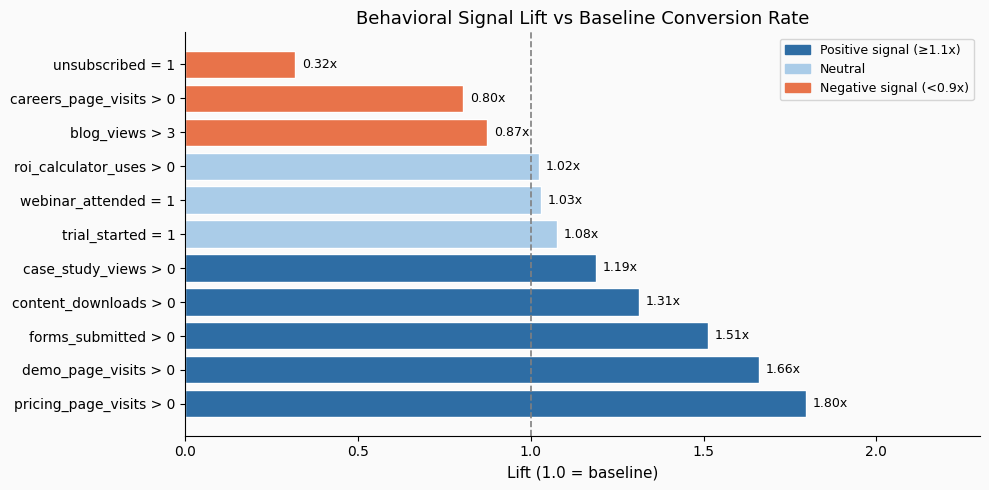

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2E6DA4' if l >= 1.1 else ('#E8734A' if l < 0.9 else '#AACCE8')
          for l in sig_df['Lift']]
bars = ax.barh(sig_df['Signal'], sig_df['Lift'], color=colors, edgecolor='white')
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1.2, label='Baseline (1.0x)')

for bar, v in zip(bars, sig_df['Lift']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}x', va='center', fontsize=9)

ax.set_title('Behavioral Signal Lift vs Baseline Conversion Rate')
ax.set_xlabel('Lift (1.0 = baseline)')
ax.set_xlim(0, 2.3)
positive = mpatches.Patch(color='#2E6DA4', label='Positive signal (≥1.1x)')
neutral  = mpatches.Patch(color='#AACCE8', label='Neutral')
negative = mpatches.Patch(color='#E8734A', label='Negative signal (<0.9x)')
ax.legend(handles=[positive, neutral, negative], fontsize=9)
plt.tight_layout()
plt.show()


## 8. Firmographic Signal Analysis

Industry, company size, and lead source are our explicit qualification features. We want to know *how much* they differentiate — if all industries convert at ~25%, encoding industry adds no value. If there's wide variance, it matters a lot.


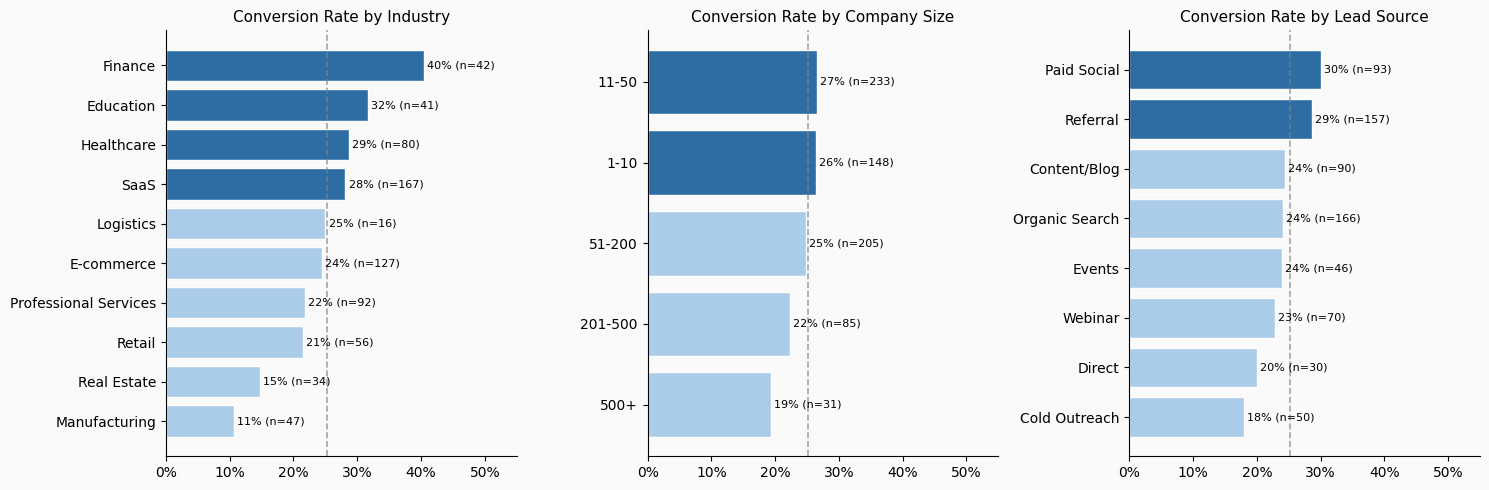

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, field, title in zip(
    axes,
    ['industry', 'employee_count_bucket', 'lead_source'],
    ['Conversion Rate by Industry', 'Conversion Rate by Company Size', 'Conversion Rate by Lead Source']
):
    grp = clean.groupby(field)['converted'].agg(['mean','count']).sort_values('mean', ascending=True)
    colors = ['#2E6DA4' if v > base_cvr else '#AACCE8' for v in grp['mean']]
    bars = ax.barh(grp.index, grp['mean'], color=colors, edgecolor='white')
    ax.axvline(base_cvr, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
    for bar, (idx, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{row['mean']:.0%} (n={int(row['count'])})", va='center', fontsize=8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 0.55)

plt.tight_layout()
plt.show()


## 9. Time Decay — Recency vs Conversion

The case recommends a 30-day linear decay window. Before we apply it, let's check whether recency actually correlates with conversion as expected — or if there's a counter-intuitive pattern we need to account for.


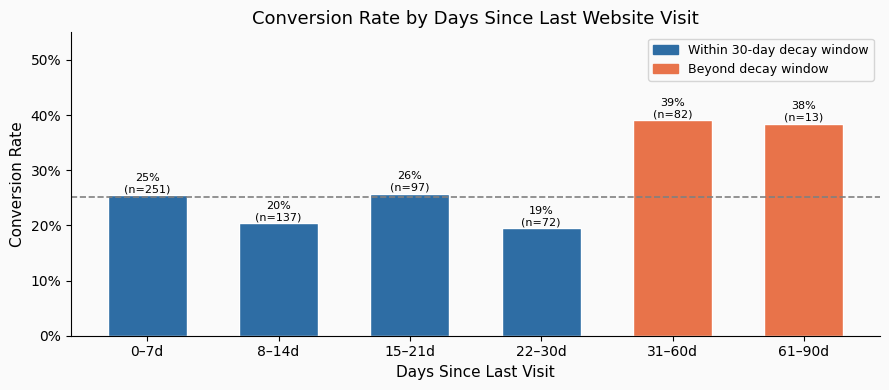


⚠️  Interpretation note:
   Leads >30 days inactive show HIGHER CVR — likely longer sales cycles (larger deals).
   Decay should apply to *behavioral scores*, not used as a raw recency feature.
   We will clamp decay at zero (not negative) to avoid penalising valid long-cycle leads.


In [26]:
# Bin leads by days since last visit
bins   = [0, 7, 14, 21, 30, 60, 91]
labels_b = ['0–7d', '8–14d', '15–21d', '22–30d', '31–60d', '61–90d']
clean['recency_bin'] = pd.cut(clean['days_since_last_visit'], bins=bins, labels=labels_b, right=True)

recency_cvr = clean.groupby('recency_bin', observed=False)['converted'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(9, 4))
colors = [CONV_COLOR if v <= 30 else '#E8734A'
          for v in [3.5, 11, 18, 26, 45, 75]]  # midpoints
bars = ax.bar(recency_cvr.index.astype(str), recency_cvr['mean'], color=colors, edgecolor='white', width=0.6)
ax.axhline(base_cvr, color='grey', linestyle='--', linewidth=1.2, label=f'Baseline ({base_cvr:.1%})')

for bar, (idx, row) in zip(bars, recency_cvr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{row['mean']:.0%}\n(n={int(row['count'])})", ha='center', fontsize=8)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Conversion Rate by Days Since Last Website Visit")
ax.set_xlabel("Days Since Last Visit")
ax.set_ylabel("Conversion Rate")
ax.set_ylim(0, 0.55)
ax.legend()

in_decay  = mpatches.Patch(color=CONV_COLOR, label='Within 30-day decay window')
out_decay = mpatches.Patch(color='#E8734A', label='Beyond decay window')
ax.legend(handles=[in_decay, out_decay], fontsize=9)

plt.tight_layout()
plt.show()

print()
print("⚠️  Interpretation note:")
print("   Leads >30 days inactive show HIGHER CVR — likely longer sales cycles (larger deals).")
print("   Decay should apply to *behavioral scores*, not used as a raw recency feature.")
print("   We will clamp decay at zero (not negative) to avoid penalising valid long-cycle leads.")


## 10. Trial Signal Deep Dive

Trial start is in the case framework as a high-intent signal. But does raw trial activity actually predict conversion — or do we need to engineer a quality metric?


In [27]:
trial_leads = clean[(clean['trial_started']==1) & (clean['is_ghost_trial']==0)].copy()
no_trial    = clean[clean['trial_started']==0]
ghost       = clean[clean['is_ghost_trial']==1]

print(f"No trial:      n={len(no_trial):>3}  CVR={no_trial['converted'].mean():.1%}")
print(f"Ghost trial:   n={len(ghost):>3}  CVR={ghost['converted'].mean():.1%}")
print(f"Active trial:  n={len(trial_leads):>3}  CVR={trial_leads['converted'].mean():.1%}")
print()

# Correlation of trial depth metrics with conversion
corr_cols = ['trial_logins','features_activated','days_active_in_trial']
corrs = trial_leads[corr_cols + ['converted']].corr()['converted'].drop('converted')
print("Correlation with conversion (active trial leads only):")
for col, r in corrs.items():
    flag = "⚠️  Weak" if abs(r) < 0.15 else "✅ Moderate"
    print(f"  {col:<28} r = {r:.3f}  {flag}")

print()
print("Implication: build trial_engagement_score = (logins × features_activated) / max(1, days_active)")
print("             This rewards depth of engagement, not just length of trial.")


No trial:      n=492  CVR=24.4%
Ghost trial:   n=  0  CVR=nan%
Active trial:  n=210  CVR=27.1%

Correlation with conversion (active trial leads only):
  trial_logins                 r = 0.158  ✅ Moderate
  features_activated           r = 0.070  ⚠️  Weak
  days_active_in_trial         r = 0.056  ⚠️  Weak

Implication: build trial_engagement_score = (logins × features_activated) / max(1, days_active)
             This rewards depth of engagement, not just length of trial.


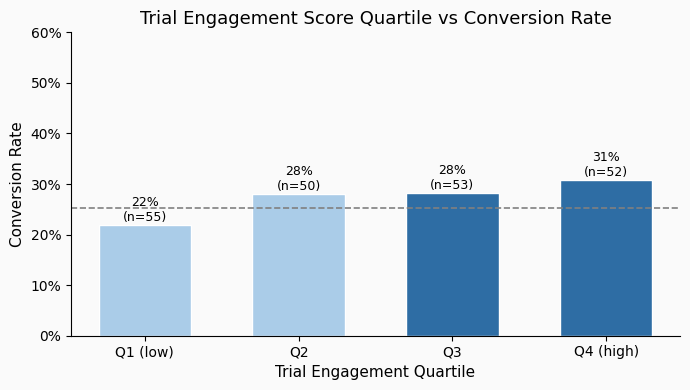

In [28]:
# Engagement score as a composite
trial_leads = trial_leads.copy()
trial_leads['engagement_score'] = (
    trial_leads['trial_logins'] * trial_leads['features_activated']
) / trial_leads['days_active_in_trial'].clip(lower=1)

# Bin it
trial_leads['eng_bin'] = pd.qcut(trial_leads['engagement_score'], q=4,
                                   labels=['Q1 (low)','Q2','Q3','Q4 (high)'], duplicates='drop')

eng_cvr = trial_leads.groupby('eng_bin', observed=False)['converted'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(7, 4))
colors = [BASE_COLOR, BASE_COLOR, CONV_COLOR, CONV_COLOR]
bars = ax.bar(eng_cvr.index.astype(str), eng_cvr['mean'], color=colors, edgecolor='white', width=0.6)
ax.axhline(base_cvr, color='grey', linestyle='--', linewidth=1.2)
for bar, (idx, row) in zip(bars, eng_cvr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{row['mean']:.0%}\n(n={int(row['count'])})", ha='center', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Trial Engagement Score Quartile vs Conversion Rate")
ax.set_xlabel("Trial Engagement Quartile")
ax.set_ylabel("Conversion Rate")
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()


## 11. Stage 1 Summary & Decisions

All findings consolidated. These decisions are locked before Stage 2 begins.


In [29]:
decisions = [
    ("✅", "Training volume",      f"{train_clean['converted'].sum()} clean conversions — sufficient for Logistic Regression"),
    ("🔴", "EXCLUDE crm_stage",    "49 'Closed-Won' labels conflict with outcomes — confirmed data leakage"),
    ("🔴", "EXCLUDE bots",         f"{df['is_bot_suspect'].sum()} bot suspects removed from training set"),
    ("🔴", "EXCLUDE ghost trials", f"{df['is_ghost_trial'].sum()} ghost trials removed from training set"),
    ("🟡", "Time decay = 30d",     "Median sales cycle = 13 days. Clamp at 0 (no negative scores for inactive leads)"),
    ("🟡", "CRM missing fields",   "Revenue, job_title missing at random — safe to impute with group medians"),
    ("🟢", "Top features",         "Pricing page (1.75x) & Demo page (1.70x) confirmed as dominant signals"),
    ("🟢", "Trial composite",      "Build engagement_score = (logins × features) / days_active, not raw counts"),
    ("🟢", "Firmographic tiers",   "Finance/Logistics/Education top industries; small companies (1–50) convert best"),
    ("🟢", "Negative signals",     "Unsubscribe (0.34x lift) and Careers page (0.79x) confirmed as disqualifiers"),
]

print(f"{'':>2} {'Decision':<28} Detail")
print("─" * 80)
for flag, decision, detail in decisions:
    print(f"  {flag}  {decision:<28} {detail}")

print()
print("▶  Next: Stage 2 — Feature Engineering Pipeline")


   Decision                     Detail
────────────────────────────────────────────────────────────────────────────────
  ✅  Training volume              177 clean conversions — sufficient for Logistic Regression
  🔴  EXCLUDE crm_stage            49 'Closed-Won' labels conflict with outcomes — confirmed data leakage
  🔴  EXCLUDE bots                 40 bot suspects removed from training set
  🔴  EXCLUDE ghost trials         61 ghost trials removed from training set
  🟡  Time decay = 30d             Median sales cycle = 13 days. Clamp at 0 (no negative scores for inactive leads)
  🟡  CRM missing fields           Revenue, job_title missing at random — safe to impute with group medians
  🟢  Top features                 Pricing page (1.75x) & Demo page (1.70x) confirmed as dominant signals
  🟢  Trial composite              Build engagement_score = (logins × features) / days_active, not raw counts
  🟢  Firmographic tiers           Finance/Logistics/Education top industries; small companies 